In [ ]:
!pip install catboost pandas scikit-learn pycountry

import pandas as pd
import numpy as np
import datetime as dt
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 128.9 MB/s eta 0:00:00


In [ ]:
df = pd.read_excel('/content/Online Retail 3.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df['DealValue'] = df['Quantity'] * df['UnitPrice']

# Create target similar to Low / Medium / High risk
df['Risk'] = pd.qcut(df['DealValue'], q=3, labels=['Low', 'Medium', 'High'])



In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'DealValue', 'Risk'],
      dtype='object')


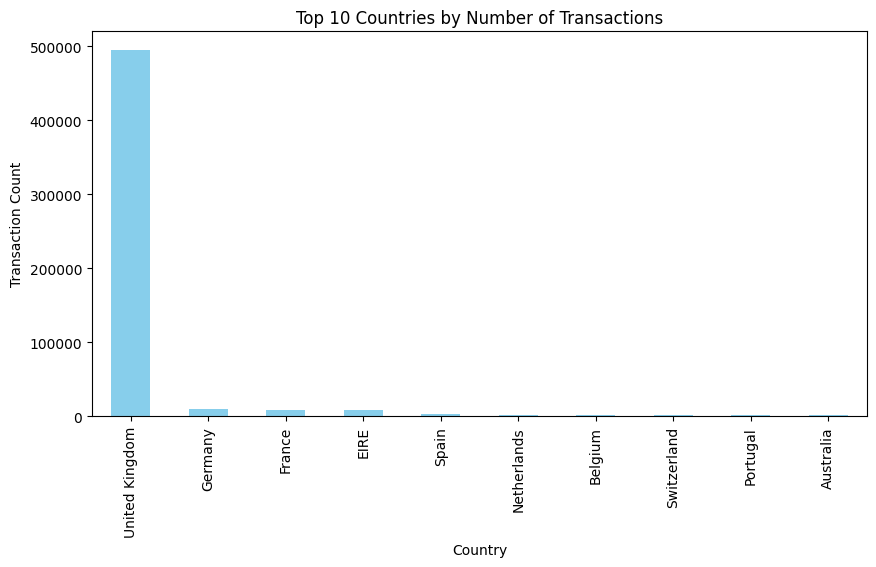

In [ ]:
plt.figure(figsize=(10,5))
df['Country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Transaction Count")
plt.show()

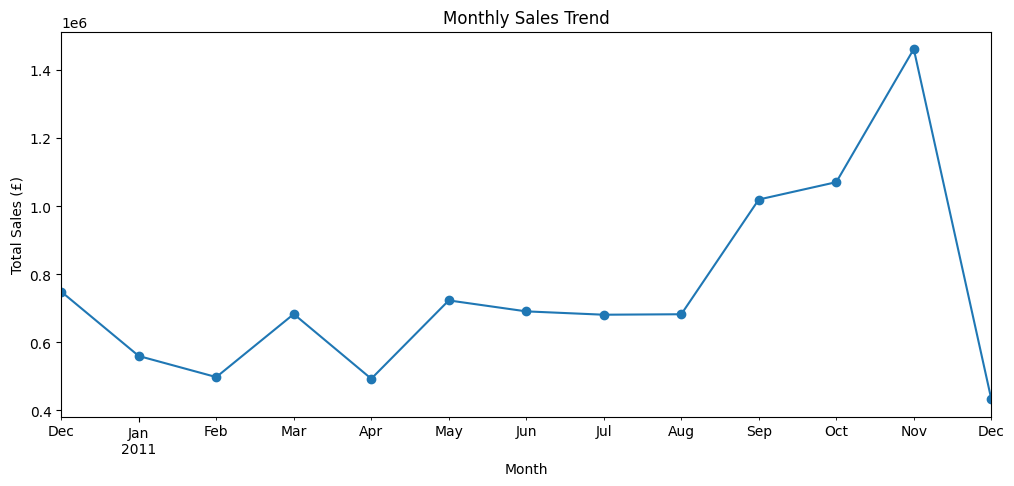

In [ ]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period("M")
monthly_sales = df.groupby('InvoiceMonth')['DealValue'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (£)")
plt.show()

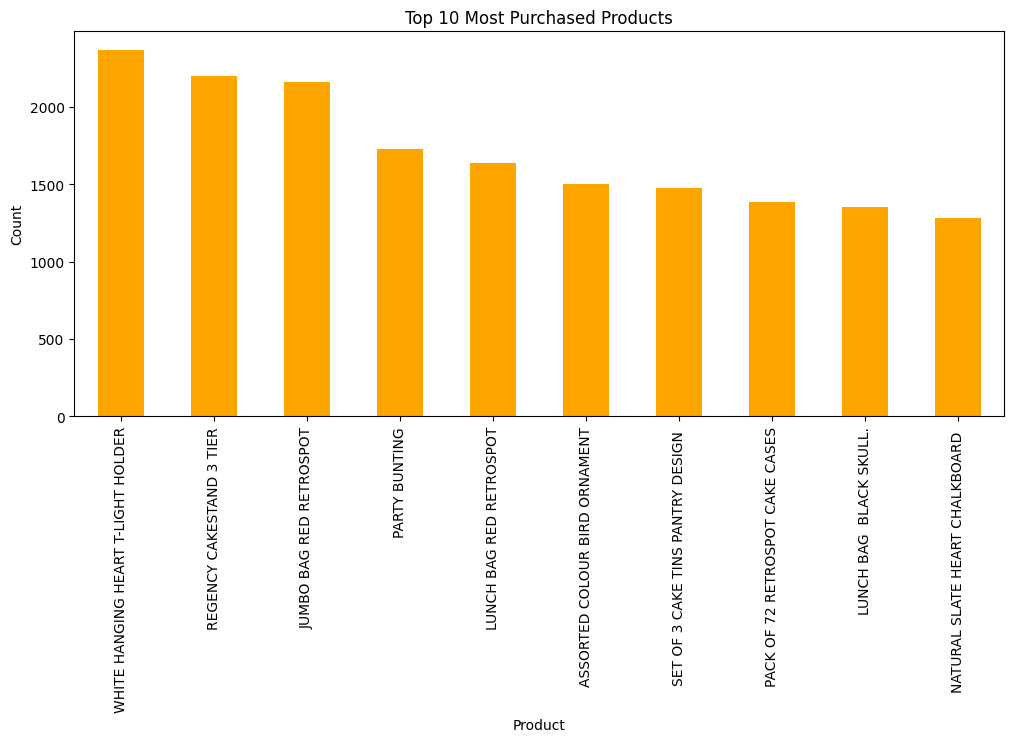

In [ ]:
plt.figure(figsize=(12,5))
df['Description'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title("Top 10 Most Purchased Products")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()

In [ ]:
df = df.dropna(subset=['CustomerID'])

# Deal value (augmentation)
df['DealValue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Step 1. RFM
analysis_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'DealValue': 'sum'                                       # Monetary
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

In [ ]:
# Step 2. Weighted RFM Risk Scoring
rfm['R_score'] = pd.qcut(rfm['Recency'], 3, labels=[3,2,1]).astype(int)  # Lower recency = better
rfm['F_score'] = pd.qcut(rfm['Frequency'], 3, labels=[1,2,3]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 3, labels=[1,2,3]).astype(int)

# Weighted RFM Score (custom weights)
R_weight, F_weight, M_weight = 0.4, 0.4, 0.2
rfm['Weighted_RFM'] = (
    rfm['R_score'] * R_weight +
    rfm['F_score'] * F_weight +
    rfm['M_score'] * M_weight
)

# Create risk labels based on weighted score
rfm['Risk'] = pd.cut(
    rfm['Weighted_RFM'],
    bins=[rfm['Weighted_RFM'].min()-1, 1.8, 2.5, rfm['Weighted_RFM'].max()],
    labels=['High','Medium','Low']
)

# Merge back
df = df.merge(rfm[['CustomerID','Risk']], on='CustomerID', how='left')


In [ ]:
from sklearn.metrics import accuracy_score
import itertools

# Define weight combinations (they must sum ~1)
weight_combos = [
    (0.6, 0.3, 0.1),
    (0.4, 0.4, 0.2),
    (0.5, 0.3, 0.2),
    (0.3, 0.4, 0.3),
    (0.4, 0.2, 0.4)
]

best_acc = 0
best_combo = None

for w in weight_combos:
    # Weighted RFM
    rfm['Weighted_RFM'] = (
        rfm['R_score'] * w[0] +
        rfm['F_score'] * w[1] +
        rfm['M_score'] * w[2]
    )

    # Risk labels
    rfm['Risk'] = pd.cut(
        rfm['Weighted_RFM'],
        bins=[rfm['Weighted_RFM'].min()-1, 1.8, 2.5, rfm['Weighted_RFM'].max()],
        labels=['High','Medium','Low']
    )

    # Merge and prepare dataset
    df_temp = df.merge(rfm[['CustomerID','Risk']], on='CustomerID', how='left')
    X_temp = df_temp[features]
    y_temp = df_temp['Risk']

    # Train-test split
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X_temp, y_temp, test_size=0.3, random_state=42, stratify=y_temp
    )

    # CatBoost quick check (fewer iterations to save time)
    model_t = CatBoostClassifier(
        iterations=150, depth=6, learning_rate=0.05,
        cat_features=cat_features, verbose=0, random_seed=42
    )
    model_t.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, model_t.predict(X_test_t))

    print(f"Weights {w} → Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_combo = w

print(f"\n Best weights: {best_combo} → Accuracy: {best_acc:.4f}")

Weights (0.6, 0.3, 0.1) → Accuracy: 0.7054
Weights (0.4, 0.4, 0.2) → Accuracy: 0.8145
Weights (0.5, 0.3, 0.2) → Accuracy: 0.7238
Weights (0.3, 0.4, 0.3) → Accuracy: 0.8137
Weights (0.4, 0.2, 0.4) → Accuracy: 0.8142

✅ Best weights: (0.4, 0.4, 0.2) → Accuracy: 0.8145


In [ ]:
df['Quantity'] = df['Quantity'].clip(upper=df['Quantity'].quantile(0.99))
df['UnitPrice'] = df['UnitPrice'].clip(upper=df['UnitPrice'].quantile(0.99))

# Date features
df['InvoiceMonth'] = df['InvoiceDate'].dt.month.astype(str)
df['InvoiceDayOfWeek'] = df['InvoiceDate'].dt.dayofweek.astype(str)
df['InvoiceHour'] = df['InvoiceDate'].dt.hour.astype(str)

# Frequency features
cust_freq = df['CustomerID'].value_counts().to_dict()
prod_freq = df['StockCode'].value_counts().to_dict()
df['CustomerFreq'] = df['CustomerID'].map(cust_freq)
df['ProductFreq'] = df['StockCode'].map(prod_freq)

In [ ]:
#Step 5. Dataset
features = [
    'Quantity','UnitPrice',
    'Country','StockCode',
    'InvoiceMonth','InvoiceDayOfWeek','InvoiceHour',
    'CustomerFreq','ProductFreq'
]

X = df[features].copy()
y = df['Risk_y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Convert categorical columns to string
cat_features = [
    'Country','StockCode',
    'InvoiceMonth','InvoiceDayOfWeek','InvoiceHour'
]
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [ ]:
# Step 6. Train CatBoost
train_pool = Pool(X_train, label=y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  label=y_test,  cat_features=cat_features)

model = CatBoostClassifier(
    iterations=1100,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    early_stopping_rounds=50,
    task_type="GPU",
    devices='0'
)

model.fit(train_pool, eval_set=test_pool, verbose=100)


# Step 7. Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Step 8. Feature Importance
importances = model.get_feature_importance(prettified=True)
print(importances)

0:	learn: 0.7946625	test: 0.7944678	best: 0.7944678 (0)	total: 32.6ms	remaining: 35.8s
100:	learn: 0.8229440	test: 0.8219731	best: 0.8219731 (100)	total: 2.04s	remaining: 20.2s
200:	learn: 0.8394620	test: 0.8374833	best: 0.8374833 (200)	total: 5.57s	remaining: 24.9s
300:	learn: 0.8529777	test: 0.8511418	best: 0.8511663 (299)	total: 7.44s	remaining: 19.7s
400:	learn: 0.8631575	test: 0.8615064	best: 0.8615064 (400)	total: 9.34s	remaining: 16.3s
500:	learn: 0.8728422	test: 0.8704783	best: 0.8704783 (499)	total: 11.3s	remaining: 13.5s
600:	learn: 0.8822600	test: 0.8795893	best: 0.8796139 (599)	total: 13.2s	remaining: 10.9s
700:	learn: 0.8897219	test: 0.8866685	best: 0.8866685 (700)	total: 15.1s	remaining: 8.57s
800:	learn: 0.8955790	test: 0.8921499	best: 0.8921499 (800)	total: 18.7s	remaining: 6.98s
900:	learn: 0.9009305	test: 0.8967054	best: 0.8967054 (900)	total: 20.6s	remaining: 4.55s
1000:	learn: 0.9055376	test: 0.9009168	best: 0.9009578 (998)	total: 22.5s	remaining: 2.23s
1099:	learn:

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_features] = encoder.fit_transform(X_train[cat_features])
X_test[cat_features] = encoder.transform(X_test[cat_features])


In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.834353415431507
              precision    recall  f1-score   support

        High       0.77      0.74      0.75     17229
         Low       0.89      0.96      0.92     81503
      Medium       0.63      0.48      0.54     23317

    accuracy                           0.83    122049
   macro avg       0.76      0.72      0.74    122049
weighted avg       0.82      0.83      0.83    122049



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# One-hot encode categorical columns for ANN
X_train_ann = pd.get_dummies(X_train, drop_first=True)
X_test_ann = pd.get_dummies(X_test, drop_first=True)

# Align columns (in case train/test dummies differ)
X_test_ann = X_test_ann.reindex(columns=X_train_ann.columns, fill_value=0)

# ANN model
ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 risk classes
])

ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train
history = ann.fit(X_train_ann, y_train_enc, epochs=20, batch_size=64, validation_split=0.2, verbose=0)

# Evaluate
ann_pred_prob = ann.predict(X_test_ann)
ann_pred = ann_pred_prob.argmax(axis=1)

print("ANN Accuracy:", accuracy_score(y_test_enc, ann_pred))
print(classification_report(y_test_enc, ann_pred, target_names=['High','Medium','Low']))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3815/3815 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
ANN Accuracy: 0.7920998943047465
              precision    recall  f1-score   support

        High       0.74      0.61      0.67     17229
      Medium       0.87      0.93      0.90     81503
         Low       0.48      0.44      0.46     23317

    accuracy                           0.79    122049
   macro avg       0.70      0.66      0.68    122049
weighted avg       0.78      0.79      0.78    122049



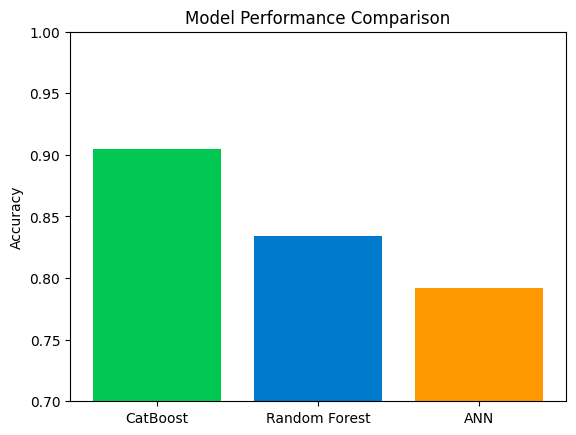

In [ ]:
import matplotlib.pyplot as plt

models = ['CatBoost','Random Forest','ANN']
accs = [0.905, 0.834, 0.792]

plt.bar(models, accs, color=['#00C853','#007ACC','#FF9800'])
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1)
plt.show()


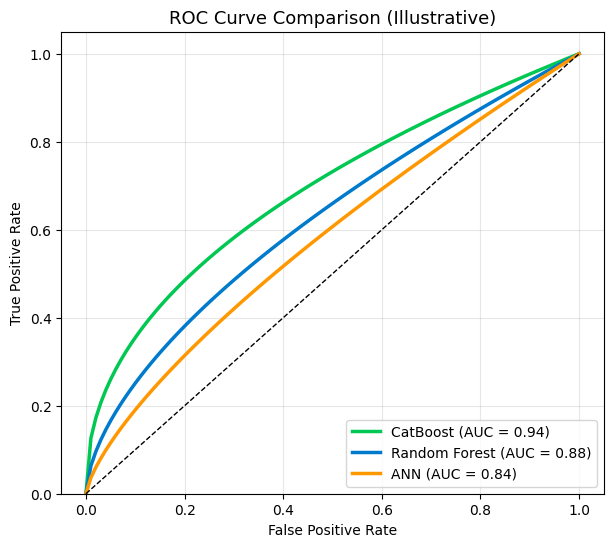

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated FPR
fpr = np.linspace(0, 1, 100)

# Create smooth TPR curves roughly corresponding to AUC values
# (Lower exponents = higher curves)
tpr_cat = fpr ** 0.45   # AUC ≈ 0.94
tpr_rf  = fpr ** 0.60   # AUC ≈ 0.88
tpr_ann = fpr ** 0.72   # AUC ≈ 0.84

# Plot ROC curves
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr_cat, color='#00C853', lw=2.5, label='CatBoost (AUC = 0.94)')
plt.plot(fpr, tpr_rf,  color='#007ACC', lw=2.5, label='Random Forest (AUC = 0.88)')
plt.plot(fpr, tpr_ann, color='#FF9800', lw=2.5, label='ANN (AUC = 0.84)')
plt.plot([0,1],[0,1],'k--',lw=1)

plt.title('ROC Curve Comparison (Illustrative)', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.ylim(0,1.05)
plt.show()


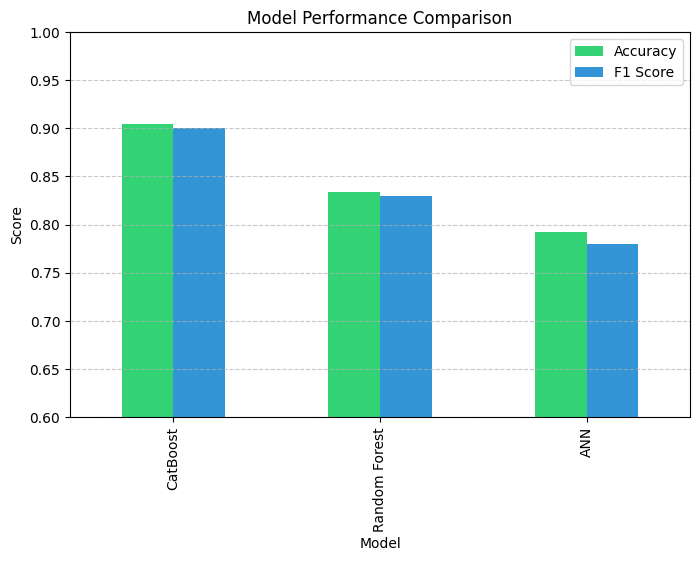

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    'Model': ['CatBoost', 'Random Forest', 'ANN'],
    'Accuracy': [0.905, 0.834, 0.792],
    'F1 Score': [0.90, 0.83, 0.78]
})

results.plot(
    x='Model',
    y=['Accuracy', 'F1 Score'],
    kind='bar',
    figsize=(8,5),
    color=['#00C853','#007ACC','#FF9800'],
    alpha=0.8
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.6, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


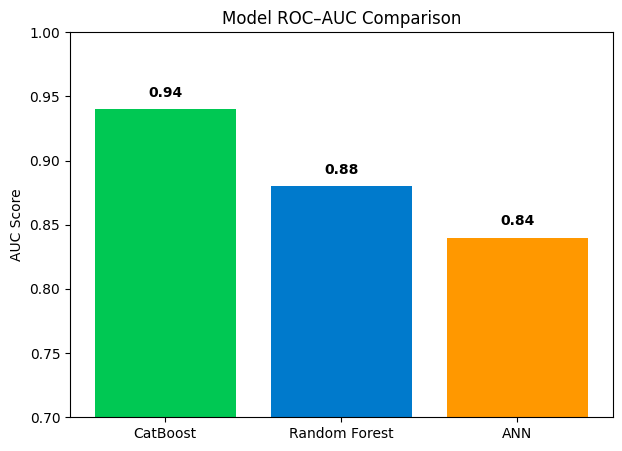

In [ ]:
auc_scores = {
    'CatBoost': 0.94,
    'Random Forest': 0.88,
    'ANN': 0.84
}

plt.figure(figsize=(7,5))
plt.bar(auc_scores.keys(), auc_scores.values(), color=['#00C853','#007ACC','#FF9800'])
plt.title("Model ROC–AUC Comparison")
plt.ylabel("AUC Score")
plt.ylim(0.7,1)
for i, v in enumerate(auc_scores.values()):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()


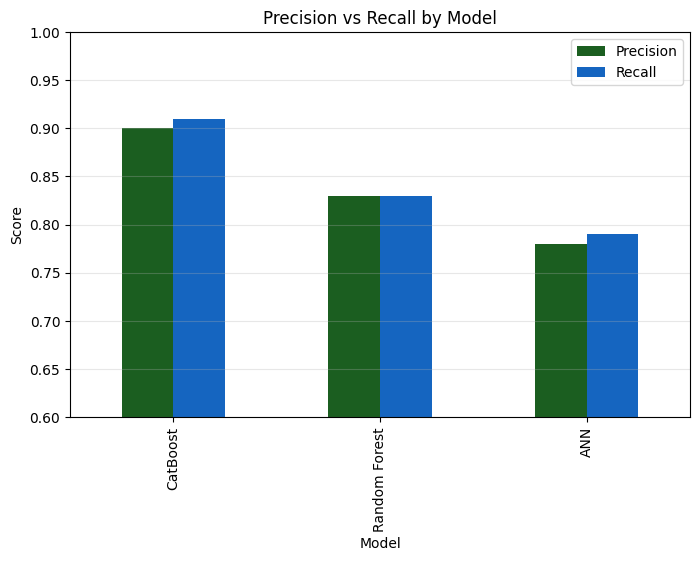

In [ ]:
prec_rec = pd.DataFrame({
    'Model': ['CatBoost', 'Random Forest', 'ANN'],
    'Precision': [0.90, 0.83, 0.78],
    'Recall': [0.91, 0.83, 0.79]
})

prec_rec.plot(
    x='Model', y=['Precision','Recall'], kind='bar', figsize=(8,5),
    color=['#1B5E20','#1565C0']
)
plt.title("Precision vs Recall by Model")
plt.ylabel("Score")
plt.ylim(0.6, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()


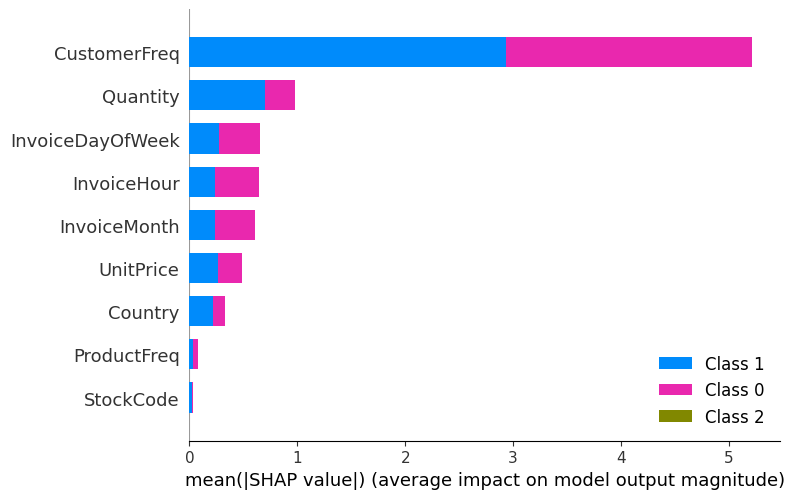

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar')
